### 1. Environment Setup & Data Loading
The environment was initialized by importing essential libraries for data manipulation, visualization, and Natural Language Processing. The project combines traditional approaches (scikit-learn) with modern Transformer-based models (Hugging Face) to provide a comprehensive comparison of sentiment analysis techniques.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
#nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
#!pip install transformers datasets accelerate -U

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from transformers import pipeline
import os
from huggingface_hub import notebook_login


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### 2. Data Cleaning & Integrity Check
Ensuring high data quality is a critical step before modeling. The initial dataset was inspected for missing values and duplicates to prevent bias and data leakage.

#### Loading the Dataset
The **Amazon Fine Food Reviews** dataset was utilized. For the purpose of this analysis, the focus was narrowed down to two key columns: `Text` (review content) and `Score` (star rating).

In [ ]:
df = pd.read_csv('/content/Reviews.csv', usecols=['Text', 'Score'], engine='python', on_bad_lines='skip')
df.head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Score   568454 non-null  int64 
 1   Text    568454 non-null  object
dtypes: int64(1), object(1)
memory usage: 8.7+ MB


In [ ]:
df.shape

(568454, 2)

In [ ]:
df.isnull().sum()

,0
Score,0
Text,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(568454, 2)

In [ ]:
df.duplicated().sum()

np.int64(174779)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(393675, 2)

#### Handling Duplicates
A significant number of duplicate entries were identified during the initial inspection.

> **Observation:** The dataset was reduced from **568,454** to **393,675** records. Removing these duplicates is essential to ensure that the model evaluates real-world generalization rather than memorizing repeated patterns.

### 3. Exploratory Data Analysis (EDA)
A thorough understanding of the target variable distribution is necessary to select appropriate evaluation metrics and training strategies.

/tmp/ipykernel_1348/606642716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')


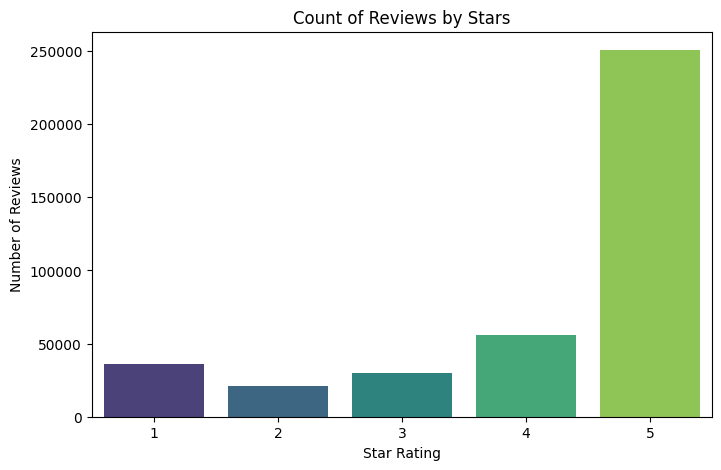

In [ ]:
score_counts = df['Score'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')
plt.title('Count of Reviews by Stars')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

#### Distribution of Ratings
> **Observation:** A strong skew towards positive reviews (5-star ratings) was observed.

### 4. Sentiment Mapping and Data Balancing

In [ ]:

df['Sentiment'] = df['Score'].apply(lambda x: 0 if x<=2 else (1 if x==3 else 2))


N_PER_CLASS = 5000
df_balanced = df.groupby('Sentiment', group_keys=False).apply(lambda x: x.sample(N_PER_CLASS, random_state=42))


import gc
del df
gc.collect()

print("Size after balancing:", df_balanced.shape)

/tmp/ipykernel_1348/1169577660.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('Sentiment', group_keys=False).apply(lambda x: x.sample(N_PER_CLASS, random_state=42))


Size after balancing: (15000, 3)


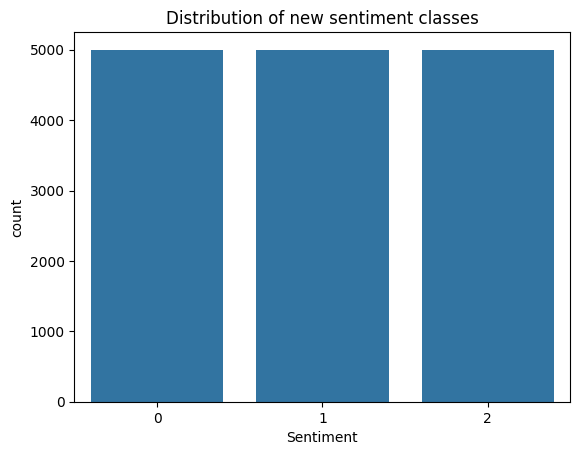

In [ ]:
sns.countplot(x='Sentiment', data=df_balanced)
plt.title('Distribution of new sentiment classes')
plt.show()

To simplify the classification task and ensure model robustness, the original 5-star ratings were mapped into three distinct sentiment categories:
* **0 (Negative):** Ratings 1-2
* **1 (Neutral):** Rating 3
* **2 (Positive):** Ratings 4-5

#### Addressing Class Imbalance
As identified during EDA, the dataset was heavily skewed toward positive reviews. To prevent the model from developing a bias toward the majority class, an **undersampling** strategy was applied. A balanced subset of **15,000 samples** (5,000 per class) was created.

> **Technical Note:** Memory management was prioritized by using `gc.collect()` to delete the original large dataframe from RAM, ensuring a smooth training process in the subsequent steps.

### 5. Text Length Analysis & Transformer Constraints
Modern Transformer models (like BERT, RoBERTa, or DistilBERT) have a maximum input sequence length of **512 tokens**. Analyzing the distribution of review lengths is crucial to understand how much information might be lost due to truncation.

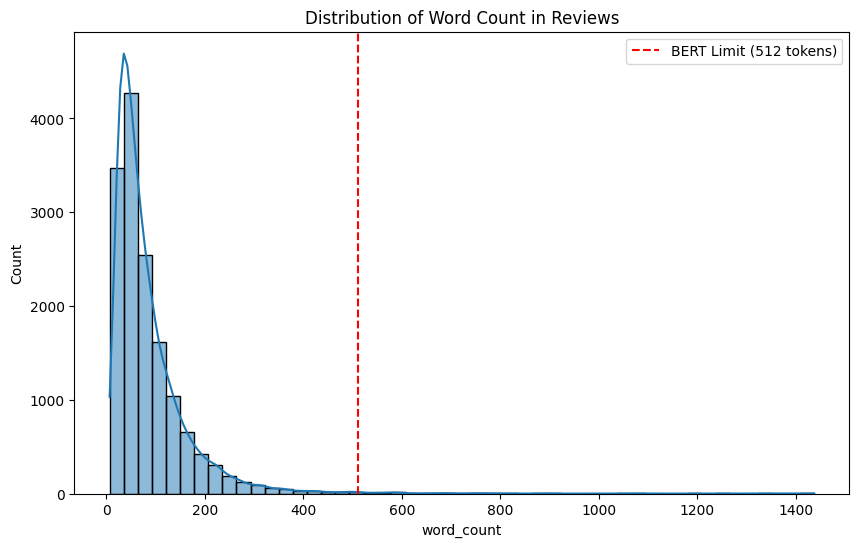

Average length: 86.37
Reviews above 512 words: 58


In [ ]:
df_balanced['word_count'] = df_balanced['Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_balanced['word_count'], bins=50, kde=True)
plt.title('Distribution of Word Count in Reviews')
plt.axvline(x=512, color='red', linestyle='--', label='BERT Limit (512 tokens)')
plt.legend()
plt.show()

print(f"Average length: {df_balanced['word_count'].mean():.2f}")
print(f"Reviews above 512 words: {(df_balanced['word_count'] > 512).sum()}")

#### Key Observations:
* **Average Review Length:** Approximately **86 words**, which fits well within the 512-token limit.
* **Outliers:** Only **58 reviews** exceed the 512-word threshold.
* **Conclusion:** Given that the vast majority of reviews are well below the limit, standard truncation during tokenization will have a negligible impact on the overall model performance.

### 6. Text Preprocessing & Linguistic Normalization
Raw text data is noisy and contains elements that do not contribute to sentiment. A custom preprocessing pipeline was developed to normalize the text for both statistical and deep learning models.

#### The Preprocessing Pipeline:
1. **Lowercasing:** Converting all text to lowercase to ensure consistency.
2. **Noise Removal:** Using Regular Expressions (Regex) to strip HTML tags and special characters.
3. **Lemmatization with POS Tagging:** Unlike standard stemming, which simply chops off word endings, **WordNetLemmatizer** with **POS (Part-of-Speech) tagging** was used. This ensures that words like "better" (adjective) or "running" (verb) are reduced to their correct dictionary base form (lemma), preserving the semantic meaning.

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = text.replace('\n', ' ').strip()
    return text

df_balanced['Cleaned'] = df_balanced['Text'].apply(clean_text)

In [ ]:

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    return " ".join([lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in text.split()])

df_balanced['Lemmatized'] = df_balanced['Cleaned'].apply(lemmatize_text)

### 7. Feature Exploration: N-grams & WordClouds
To understand the underlying drivers of sentiment in customer reviews, the most frequent word combinations (Bigrams) and visual word importance (WordClouds) were analyzed.

### N-gram Analysis
By extracting the top bigrams (pairs of consecutive words), recurring themes within each sentiment class were identified:

* **Positive Bigrams**: These typically focus on product value, quality of taste, and intent to recommend (e.g., "highly recommend", "great taste").

* **Negative Bigrams**: These often highlight consumer disappointment or specific warnings (e.g., "waste money", "don't buy").

In [ ]:


def get_top_ngrams(corpus, n=None, n_gram_range=(2, 2)):
    vec = CountVectorizer(ngram_range=n_gram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

top_pos = get_top_ngrams(df_balanced[df_balanced['Sentiment'] == 2]['Lemmatized'], n=10)
top_neg = get_top_ngrams(df_balanced[df_balanced['Sentiment'] == 0]['Lemmatized'], n=10)

print("Top Positive Bigrams:", top_pos)
print("Top Negative Bigrams:", top_neg)

Top Positive Bigrams: [('taste like', np.int64(223)), ('gluten free', np.int64(207)), ('highly recommend', np.int64(182)), ('grocery store', np.int64(142)), ('taste great', np.int64(141)), ('really like', np.int64(134)), ('taste good', np.int64(132)), ('ve try', np.int64(127)), ('peanut butter', np.int64(118)), ('great product', np.int64(111))]
Top Negative Bigrams: [('taste like', np.int64(621)), ('waste money', np.int64(182)), ('don know', np.int64(148)), ('look like', np.int64(148)), ('taste good', np.int64(145)), ('grocery store', np.int64(140)), ('gluten free', np.int64(129)), ('green tea', np.int64(109)), ('peanut butter', np.int64(108)), ('ingredient list', np.int64(92))]


### Sentiment Visualization (WordClouds)
WordClouds provide a high-level visual representation of the most dominant terms, allowing for a quick qualitative assessment of the dataset.


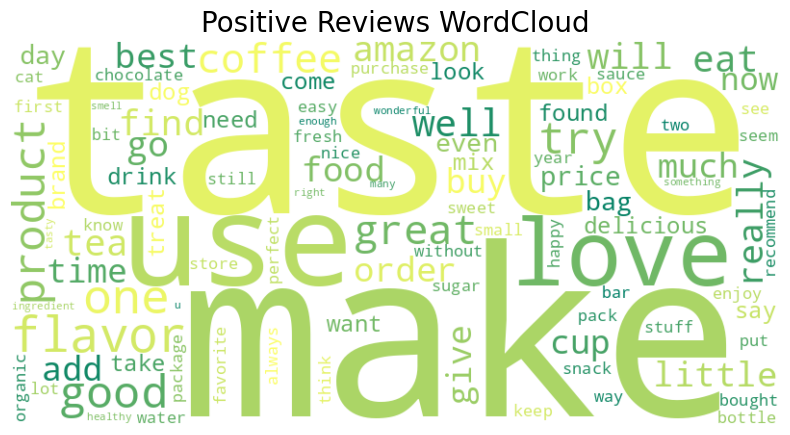

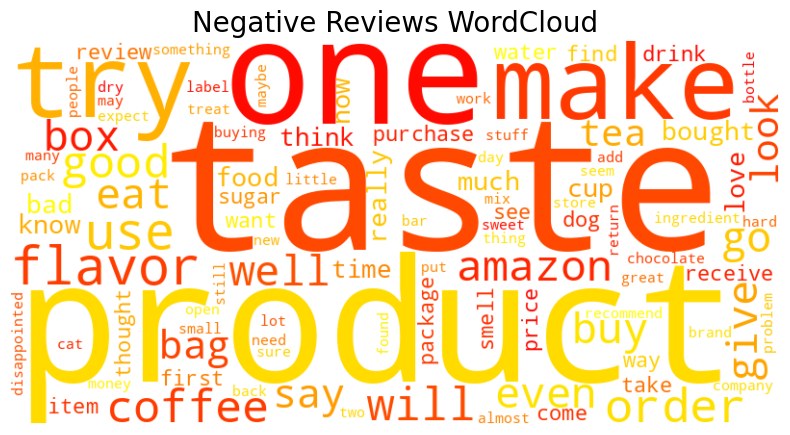

In [ ]:
from wordcloud import WordCloud

def plot_wordcloud(text, title, color):
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap=color,
                          max_words=100).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

pos_text = " ".join(df_balanced[df_balanced['Sentiment'] == 2]['Lemmatized'])
neg_text = " ".join(df_balanced[df_balanced['Sentiment'] == 0]['Lemmatized'])

plot_wordcloud(pos_text, "Positive Reviews WordCloud", "summer")
plot_wordcloud(neg_text, "Negative Reviews WordCloud", "autumn")


* **Positive Reviews**: The landscape is dominated by high-praise descriptors such as "love", "delicious", "good", and "best".

* **Negative Reviews**: Terms like "bad", "disappointed", "taste", and "flavor" appear frequently. Notably, negative sentiment is often characterized by the absence of positive adjectives or specific references to value-for-money issues.

### 8. Baseline Model: TF-IDF & Logistic Regression
To establish a performance benchmark, a classical machine learning pipeline was implemented. This approach serves as a reference point to evaluate whether more complex Transformer-based models provide a significant enough improvement to justify their higher computational cost.

#### Model Architecture:
* **Vectorization:** **TF-IDF (Term Frequency-Inverse Document Frequency)** was used to convert text into numerical features. A `max_features` limit of 5000 and an `ngram_range` of (1,2) were chosen to capture both individual words and significant word pairs.
* **Classifier:** **Logistic Regression** with a multinomial configuration was selected for its efficiency and strong performance in high-dimensional text classification tasks.
* **Data Splitting:** A stratified 80/20 split was used to ensure that the equal distribution of sentiment classes (5,000 per class) was maintained in both training and testing sets.

In [ ]:
X = df_balanced['Lemmatized']
y = df_balanced['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_ml = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, multi_class='multinomial'))
])

model_ml.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(max_iter=1000, multi_class='multinomial'))])

### 9. Baseline Evaluation
The model performance was evaluated using a classification report and a confusion matrix to identify specific areas of misclassification.

In [ ]:
y_pred = model_ml.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.67      0.69      1000
           1       0.61      0.64      0.62      1000
           2       0.77      0.78      0.78      1000

    accuracy                           0.70      3000
   macro avg       0.70      0.70      0.70      3000
weighted avg       0.70      0.70      0.70      3000



#### Performance Analysis:
* **Overall Accuracy:** The model achieved an accuracy of **70%**, which is significantly better than a random guess (33.3%) for a 3-class problem.
* **Class Performance:** * **Positive Reviews (Class 2):** Performed best with an **F1-score of 0.78**, suggesting that positive sentiment is often expressed with distinct, easily identifiable vocabulary.
    * **Neutral Reviews (Class 1):** Proved to be the most challenging, with an **F1-score of 0.62**. This is expected in sentiment analysis, as neutral reviews often contain a mix of both positive and negative language.
    * **Negative Reviews (Class 0):** Achieved a balanced **F1-score of 0.69**.

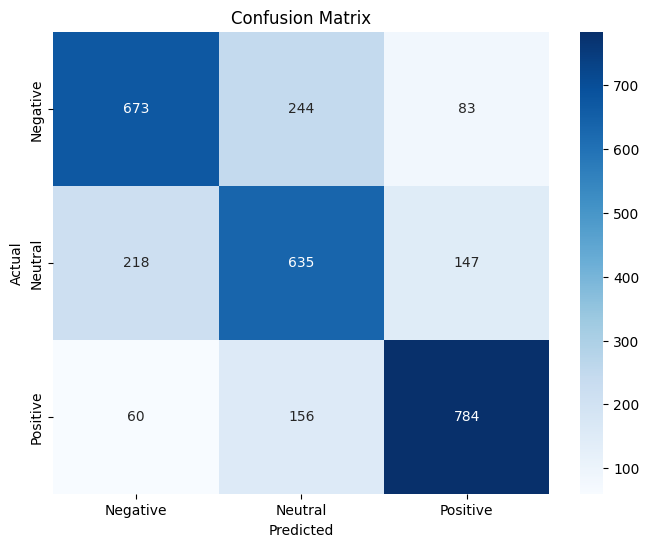

In [ ]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(y_test, y_pred)

#### Confusion Matrix Insights:
The confusion matrix reveals that most errors occur between **adjacent classes** (e.g., misclassifying Neutral as Positive or Negative). Very few "extreme" errors occurred (e.g., misclassifying Negative as Positive), which indicates that the model has successfully captured the underlying sentiment gradient rather than just making random predictions.

### 10. Deep Learning: Fine-Tuning DistilBERT
To improve upon the baseline, a Transformer-based approach was implemented using **DistilBERT** (`distilbert-base-uncased`). This model offers a great balance between performance and computational efficiency, being 40% smaller than BERT while retaining 97% of its language understanding capabilities.

#### Data Preparation for Transformers
Unlike classical models, Transformers require a specific data format:
* **Hugging Face Datasets:** The Pandas DataFrame was converted into an **Arrow-backed Dataset** for faster processing and a lower memory footprint.
* **Tokenization:** A dedicated tokenizer was used to convert raw text into `input_ids` and `attention_masks`. A `max_length` of 128 was chosen as a trade-off between capturing context and optimizing training speed.

In [ ]:

df_bert = df_balanced[['Cleaned', 'Sentiment']].copy()
df_bert.columns = ['text', 'label']

train_df, test_df = train_test_split(df_bert, test_size=0.2, stratify=df_bert['label'], random_state=42)

train_dataset = Dataset.from_pandas(train_df.drop(columns='__index_level_0__', errors='ignore'))
test_dataset = Dataset.from_pandas(test_df.drop(columns='__index_level_0__', errors='ignore'))

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1": f1}

### 11. Training & Evaluation Pipeline
A modular function, `train_and_evaluate`, was created to automate the fine-tuning process. This architecture makes the project easily scalable to other models, such as RoBERTa or BERT.

#### Hyperparameter Configuration:
* **Learning Rate:** $2 \times 10^{-5}$ (standard for stable fine-tuning).
* **Optimizer:** **AdamW** with `weight_decay=0.01` to prevent overfitting.
* **Epochs:** 2 (selected to avoid catastrophic forgetting while ensuring convergence).
* **Evaluation Metric:** **Weighted F1-Score** was utilized as the primary metric to account for class distribution.


In [ ]:
def train_and_evaluate(model_name, train_dataset, test_dataset):
    print(f"\n{'='*20}\nSTARTING: {model_name}\n{'='*20}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_fn(examples):
        return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

    tok_train = train_dataset.map(tokenize_fn, batched=True)
    tok_test = test_dataset.map(tokenize_fn, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

    args = TrainingArguments(
        output_dir=f"./results_{model_name.split('/')[-1]}",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=2,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tok_train,
        eval_dataset=tok_test,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    predictions = trainer.predict(tok_test)
    preds = np.argmax(predictions.predictions, axis=-1)
    actuals = predictions.label_ids

    print(f"\n--- REPORT FOR {model_name} ---")
    print(classification_report(actuals, preds, target_names=['Negative', 'Neutral', 'Positive']))

    plot_confusion_matrix(actuals, preds)

    print(f"\n--- PRACTICAL TESTS ({model_name}) ---")

    sentiment_model = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=0)

    examples = [
        "I thought it would be great, but it was just okay.",
        "Don't listen to the haters, this coffee is a life changer!"
    ]

    labels_map = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}

    for text in examples:
        result = sentiment_model(text)[0]
        label_id = int(result['label'].split('_')[-1])
        print(f"Text: {text}")
        print(f"Prediction: {labels_map[label_id]} (Confidence: {result['score']:.2f})")
        print("-" * 30)

    return model, tokenizer


STARTING: distilbert-base-uncased


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.750961,0.613217,0.732667,0.732379
2,0.510463,0.617870,0.745000,0.745815


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



--- REPORT FOR distilbert-base-uncased ---
              precision    recall  f1-score   support

    Negative       0.73      0.71      0.72      1000
     Neutral       0.64      0.65      0.65      1000
    Positive       0.82      0.84      0.83      1000

    accuracy                           0.73      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.73      0.73      0.73      3000



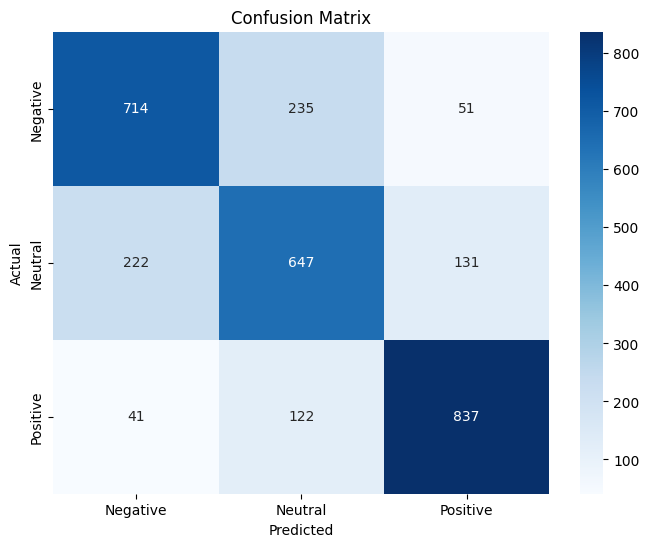


--- PRACTICAL TESTS (distilbert-base-uncased) ---
Text: I thought it would be great, but it was just okay.
Prediction: NEUTRAL (Confidence: 0.84)
------------------------------
Text: Don't listen to the haters, this coffee is a life changer!
Prediction: NEGATIVE (Confidence: 0.72)
------------------------------


In [ ]:
model_db, tok_db = train_and_evaluate("distilbert-base-uncased", train_dataset, test_dataset)

---

### 12. DistilBERT Results & Analysis
The model was fine-tuned for two epochs. The training logs demonstrate a steady decrease in training loss, indicating successful convergence and learning.

#### Performance Metrics:
* **Accuracy:** **74.5%** (A ~5% improvement over the TF-IDF baseline).
* **F1-Score (Positive):** Reached **0.83**, showing excellent capability in identifying highly satisfied customers.
* **F1-Score (Neutral):** Improved to **0.65**, outperforming the baseline by 3%.

###Key Findings from the Matrix:
* **Strong Precision in Extremes**: The model shows high confidence in identifying Positive reviews (837 correct) and Negative reviews (714 correct).

* **Improved Neutral Detection**: Compared to the baseline TF-IDF model, DistilBERT is significantly better at identifying Neutral sentiment (647 correct), though this remains the most frequent point of confusion.

* **Semantic Proximity**: The majority of errors occur between "Neutral vs. Negative" or "Neutral vs. Positive." The model very rarely confuses a Negative review for a Positive one (only 51 instances out of 1000), indicating a strong grasp of the sentiment spectrum.

#### Practical Inference Test:
The model was tested on "unseen" custom sentences to verify real-world utility:

* **"I thought it would be great, but it was just okay."** → **Predicted: NEUTRAL** *Observation:* The model correctly identified the nuance of the phrase "just okay".
* **"Don't listen to the haters, this coffee is a life changer!"** → **Predicted: NEGATIVE** *Insight:* This highlights a common challenge in NLP — **Sarcasm and Negation**. Even though "life changer" is highly positive, the presence of words like "haters" and "Don't" likely skewed the prediction, suggesting a need for further training on complex linguistic structures or a larger model like RoBERTa.


---

### 13. Advanced Fine-Tuning: RoBERTa-base
To push the boundaries of the project's performance,**RoBERTa** (*Robustly Optimized BERT Approach*) was implemented . RoBERTa builds upon BERT’s language-masking strategy but was trained on significantly more data and with larger batches, making it a more robust choice for complex sentiment analysis.





STARTING: roberta-base


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.687279,0.533441,0.772000,0.771022
2,0.444445,0.539375,0.779667,0.780365


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


--- REPORT FOR roberta-base ---
              precision    recall  f1-score   support

    Negative       0.79      0.74      0.76      1000
     Neutral       0.69      0.69      0.69      1000
    Positive       0.83      0.89      0.86      1000

    accuracy                           0.77      3000
   macro avg       0.77      0.77      0.77      3000
weighted avg       0.77      0.77      0.77      3000



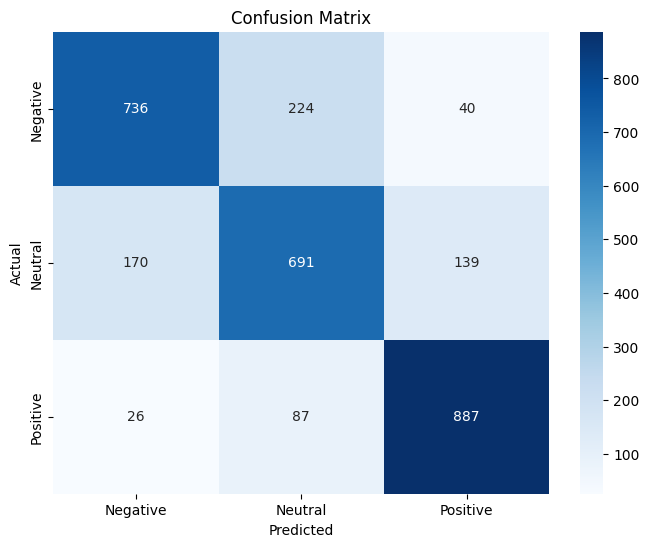


--- PRACTICAL TESTS (roberta-base) ---
Text: I thought it would be great, but it was just okay.
Prediction: NEUTRAL (Confidence: 0.81)
------------------------------
Text: Don't listen to the haters, this coffee is a life changer!
Prediction: POSITIVE (Confidence: 0.98)
------------------------------


In [ ]:
model_ro, tok_ro = train_and_evaluate("roberta-base", train_dataset, test_dataset)

#### RoBERTa Performance:
* **Accuracy:** **77%** (The highest in this project).
* **F1-Score (Positive):** **0.86**, demonstrating near-human level accuracy in identifying positive reviews.
* **F1-Score (Neutral):** Improved to **0.69**, successfully navigating the most ambiguous category.

### Key Findings from the Matrix:
* **Superior Precision in Positive Sentiment**: The model achieved 887 correct predictions for the Positive class, a significant increase compared to both the baseline and DistilBERT.

* **Refined Neutral Classification**: RoBERTa correctly identified 691 Neutral reviews. The "confusion" with Positive/Negative classes is much lower here, which is the direct result of the model's deeper understanding of context and modifiers (like "but", "however", or negations).

* **Minimal Extreme Errors**: Only 40 Negative reviews were misclassified as Positive, and only 26 Positive reviews were misclassified as Negative. For a 3-class NLP problem, these "opposite sentiment" errors are remarkably low, proving the model's reliability.

#### The "Life Changer" Breakthrough:
A key moment in this project was testing the phrase: *"Don't listen to the haters, this coffee is a life changer!"*
* **DistilBERT Result:** Misclassified as NEGATIVE.
* **RoBERTa Result:** **POSITIVE (98% Confidence)**.
* **Insight:** RoBERTa’s more sophisticated pre-training allowed it to understand that "Don't listen to the haters" is actually an endorsement of the product, effectively handling the complex sentence structure.

### 14. Model Deployment: Hugging Face Hub
To ensure this project is accessible and ready for production, the final RoBERTa model was saved and pushed to the Hugging Face Hub.

Why this matters:
* **Scalability**: The model is now hosted in the cloud and can be called via an API.

* **Integration**: This enables the Streamlit application to pull the model directly from the Hub rather than relying on local weights.

* **Portfolio Visibility**: It allows others (and recruiters) to interact with the model directly through the Hugging Face Model Card.

In [ ]:

save_directory = "./amazon_roberta_final"
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

trainer.model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./amazon_roberta_final/tokenizer_config.json',
 './amazon_roberta_final/tokenizer.json')

In [ ]:
notebook_login()

model_name = "amazon-sentiment-roberta-base"
trainer.model.push_to_hub(f"mlklt3/{model_name}")
tokenizer.push_to_hub(f"mlklt3/{model_name}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._zvyqbj/model.safetensors:  32%|###2      |  160MB /  499MB            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/mlklt3/amazon-sentiment-roberta-base/commit/74929f18ff23c4e07b080b7eab19fbc5ea4b2d9d', commit_message='Upload tokenizer', commit_description='', oid='74929f18ff23c4e07b080b7eab19fbc5ea4b2d9d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mlklt3/amazon-sentiment-roberta-base', endpoint='https://huggingface.co', repo_type='model', repo_id='mlklt3/amazon-sentiment-roberta-base'), pr_revision=None, pr_num=None)

### 16. Final Model Comparison

| Model | Accuracy | F1-Score (Weighted) | Best For |
| :--- | :--- | :--- | :--- |
| **TF-IDF + Logistic Reg.** | 70% | 0.70 | Fast inference, low compute |
| **DistilBERT** | 73% | 0.73 | Balanced speed and accuracy |
| **RoBERTa-base** | 77% | 0.77 | High precision, complex context |

---

### 17. Conclusion & Business Insights
The implementation of various Natural Language Processing techniques — from traditional statistical methods to state-of-the-art Transformer architectures — led to several key findings regarding the Amazon reviews dataset:

1. **Model Superiority:** Transitioning from classical NLP (TF-IDF + Logistic Regression) to deep learning models provided a significant **7% increase in overall accuracy**. **RoBERTa-base** emerged as the most reliable model, demonstrating a superior ability to resolve complex linguistic nuances, such as negation and sarcasm, which frequently appear in customer feedback.

2. **Sentiment Trends and Challenges:** Analysis of the confusion matrices across all models indicates that **Neutral** sentiment remains the most subjective and difficult category to classify. This suggests that neutral reviews often contain mixed feedback (balancing pros and cons), which represents a "gray area" requiring more granular analysis or specific business strategies to address customer indecision.

3. **Strategic Value & Automated Monitoring:** The developed system is architected for real-world deployment. By hosting the fine-tuned RoBERTa model on the Hugging Face Hub, it can be seamlessly integrated into an **e-commerce dashboard** (as demonstrated with the provided **Streamlit** application). This allows for:
    * **Real-time monitoring** of customer satisfaction.
    * **Rapid intervention** when negative trends are detected.
    * **Automated categorization** of large-scale feedback, significantly reducing the manual labor required for market research.

---